In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df_customers = pd.read_csv('Data\olist_customers_dataset.csv')
df_geolocation = pd.read_csv('Data\olist_geolocation_dataset.csv')
df_order_items = pd.read_csv('Data\olist_order_items_dataset.csv')
df_payments = pd.read_csv('Data\olist_order_payments_dataset.csv') 
df_reviews = pd.read_csv('Data\olist_order_reviews_dataset.csv')
df_orders = pd.read_csv('Data\olist_orders_dataset.csv')
df_products = pd.read_csv('Data\olist_products_dataset.csv')
df_sellers = pd.read_csv('Data\olist_sellers_dataset.csv')
df_prdduct_category = pd.read_csv('Data\product_category_name_translation.csv')

In [3]:
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [4]:
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])
df_orders['order_approved_at'] = pd.to_datetime(df_orders['order_approved_at'])
df_orders['order_delivered_carrier_date'] = pd.to_datetime(df_orders['order_delivered_carrier_date'])
df_orders['order_delivered_customer_date'] = pd.to_datetime(df_orders['order_delivered_customer_date'])
df_orders['order_estimated_delivery_date'] = pd.to_datetime(df_orders['order_estimated_delivery_date'])

In [5]:
df_orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [6]:
df_orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [7]:
df_orders.duplicated().sum()

np.int64(0)

In [8]:
df_orders[df_orders['order_delivered_customer_date'].isnull()]['order_status'].value_counts()

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

The null values in columns 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date' are because of the different delivery_status of those orders than "delivered" which means orders are not completed so they are at different stages of delivery i.e 'shipped', 'invoiced, processing, created or approved and some of the deliveries are cancelled or items for those orders are not available 

# KPI

In [9]:
cancelled_orders = df_orders[df_orders['order_status'] == 'canceled']
unavailable_orders = df_orders[df_orders['order_status'] == 'unavailable']
valid_orders = df_orders[(df_orders['order_status'] != 'canceled') & (df_orders['order_status'] != 'unavailable')]
completed_orders = df_orders[df_orders['order_status'] == 'delivered']

In [10]:
total_orders = df_orders['order_id'].nunique()
canceled_orders_count = cancelled_orders['order_id'].nunique()
completed_orders_count = completed_orders['order_id'].nunique()
unavailable_orders_count = unavailable_orders['order_id'].nunique()

print('Total Orders :', total_orders)
print('cancelled Orders :', canceled_orders_count)
print('unavailable Orders :', unavailable_orders_count)
print('completed orders :', completed_orders_count)

print(f'completed orders % : {round(completed_orders_count/total_orders*100 , 2)}%' )
print(f'canceled orders % : {round(canceled_orders_count/total_orders*100 , 2)}%')
print(f'unavailable orders % : {round(unavailable_orders_count/total_orders*100 , 2)}%' )


Total Orders : 99441
cancelled Orders : 625
unavailable Orders : 609
completed orders : 96478
completed orders % : 97.02%
canceled orders % : 0.63%
unavailable orders % : 0.61%


In [11]:
df_order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


In [12]:
df_order_items['item_price'] = df_order_items['price'] + df_order_items['freight_value']
df_order_items['shipping_limit_date'] = pd.to_datetime(df_order_items['shipping_limit_date'])

In [13]:
orders_items_summary = df_order_items.groupby('order_id').agg(items = ('order_id', 'value_counts'), order_value = ('item_price', 'sum'), shipping_limit_date = ('shipping_limit_date', 'nunique'), 
                                                              sale = ('price', 'sum'), freight_cost = ('freight_value', 'sum')).reset_index()
orders_items_summary.head()

,order_id,items,order_value,shipping_limit_date,sale,freight_cost
0,00010242fe8c5a6d1ba2dd792cb16214,1,72.19,1,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,259.83,1,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,216.87,1,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,25.78,1,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,218.04,1,199.90,18.14


In [14]:
print(orders_items_summary[orders_items_summary['shipping_limit_date'] >1].shape[0])
print(orders_items_summary[orders_items_summary['items'] >1].shape[0])


336
9803


There are 336 orders having different shipping_limit_time (deadline) for each item to deliver carrier, order_items_summary consists total price of order for all items icluding freight charges, there are 9803 orders that contain multiple items
 

In [15]:
valid_orders = valid_orders.merge(orders_items_summary, how='left', on = 'order_id')
valid_orders.shape[0]

98207

In [16]:
valid_orders[valid_orders['order_value'].isnull()]['order_status'].value_counts()

order_status
created     5
invoiced    2
shipped     1
Name: count, dtype: int64

The order value for orders created, invoiced and shipped is null

# Total Sales

In [17]:
print(f"Total Revenue : {round(valid_orders['sale'].sum()/1e6,2)}M $")
print(f"Total Freight Cost : {round(valid_orders['freight_cost'].sum()/1e6,2)} $")

Total Revenue : 13.49M $
Total Freight Cost : 2.24 $


# Supply Chain Analysis

In [18]:
orders_timeline = df_order_items.merge(df_orders, how= 'left', on = 'order_id')

In [19]:
orders_timeline.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 15 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       112650 non-null  str           
 1   order_item_id                  112650 non-null  int64         
 2   product_id                     112650 non-null  str           
 3   seller_id                      112650 non-null  str           
 4   shipping_limit_date            112650 non-null  datetime64[us]
 5   price                          112650 non-null  float64       
 6   freight_value                  112650 non-null  float64       
 7   item_price                     112650 non-null  float64       
 8   customer_id                    112650 non-null  str           
 9   order_status                   112650 non-null  str           
 10  order_purchase_timestamp       112650 non-null  datetime64[us]
 11  order_appro

some of the orders are only in approved or shipped or just created so for those orders the "order_delivered_carrier_date", 'order_delivered_customer_date',  and "order_approved_at" have some null values

In [20]:
orders_timeline['shipping_diff_hours'] = ((orders_timeline['order_delivered_carrier_date'] - orders_timeline['shipping_limit_date']).dt.total_seconds() / 3600)
orders_timeline['delivery_diff_hours'] = ((orders_timeline['order_delivered_customer_date'] - orders_timeline['order_estimated_delivery_date']).dt.total_seconds()/3600)
orders_timeline['approval_timediff_hours']  =( orders_timeline['order_approved_at'] - orders_timeline['order_purchase_timestamp']).dt.total_seconds()/3600


In [21]:
orders_timeline['carrier_delivery_flag'] = np.where(orders_timeline['shipping_diff_hours'] <= 0, 'on_time', 'late' )
orders_timeline['delivery_flag'] = np.where(orders_timeline['delivery_diff_hours'] <= 0, 'on_time', 'late')
orders_timeline['approval_flag'] = np.where((orders_timeline['approval_timediff_hours'] >= 0) & (orders_timeline['approval_timediff_hours'] < 48), 'on_time', 'late')

### Which sellers are delivering order items late to (after the shipping_limit_date) carrier/ shipping ?

In [22]:
## of everything this seller shipped, what fraction of items were late?" Fine for an ops/fulfillment-accuracy view.
##total_orders = ('order_id', 'count'),   # total items handled by this seller
## late_orders  = ('carrier_delivery_flag', lambda x: (x == 'late').sum()) 

###of this seller's distinct orders, what fraction had at least one late item?
## total_orders = ('order_id', 'nunique'),
## late_orders  = ('order_id', lambda x: x[carrier_delivery_info.loc[x.index,'carrier_delivery_flag']=='late'].nunique())


In [23]:
### the table containing the order items that got delivered to carrier
carrier_delivery_info = orders_timeline[orders_timeline['order_delivered_carrier_date'].notnull()]


### we have considered order items here and not the orders so as to know how many items were delivered on time to the carrier by seller 
seller_delivery_carrier = carrier_delivery_info.groupby('seller_id').agg(
    total_orders = ('order_id', 'nunique'),
    late_orders  = ('order_id', lambda x: x[carrier_delivery_info.loc[x.index,'carrier_delivery_flag']=='late'].nunique()),
    revenue=('price', 'sum')
).reset_index()

seller_delivery_carrier['late_rate_pct'] = round(seller_delivery_carrier['late_orders'] * 100 / seller_delivery_carrier['total_orders'], 2)

seller_delivery_carrier[seller_delivery_carrier['total_orders'] >= 10].sort_values('late_orders', ascending=False).head(10)

,seller_id,total_orders,late_orders,revenue,late_rate_pct
1481,7c67e1448b00f6e969d365cea6b010ab,980,290,187473.91,29.59
188,1025f0e2d44d7041d6cf58b6550e0bfa,915,162,138968.55,17.70
858,4a3ca9315b744ce9f8e9374361493884,1805,157,200383.02,8.70
358,1f50f920176fa81dab994f9023523100,1404,154,106939.21,10.97
712,3d871de0142ce09b7081e2b9d1733cb1,1078,140,94776.20,12.99
79,06a2c3af7b3aee5d69171b0e14f0ee87,392,123,36408.95,31.38
1609,88460e8ebdecbfecb5f9601833981930,246,117,31320.40,47.56
993,53e4c6e0f4312d4d2107a8c9cddf45cd,470,98,29898.01,20.85
1534,8160255418d5aaa7dbdc9f4c64ebda44,385,96,47017.69,24.94
1735,92eb0f42c21942b6552362b9b114707d,340,91,6533.76,26.76


##### These are the top 10 sellers who are delivering the order late to the carrier/shipping, we can inform them to deliver the order items on time to improve delivery time to the customer

In [24]:
print(f"number orders late to reach carrier  :{carrier_delivery_info[carrier_delivery_info['carrier_delivery_flag'] != 'on_time']['order_id'].nunique()}")
print(f"% of  orders late to reach carrier  :{round(carrier_delivery_info[carrier_delivery_info['carrier_delivery_flag'] != 'on_time']['order_id'].nunique()*100/df_orders.shape[0], 2)} %")

number orders late to reach carrier  :8861
% of  orders late to reach carrier  :8.91 %


### how many orders are getting late approval (after 2 days) ? is it impacting the deliveries to the customer ?

In [25]:
### the table containing theto carrier
approved_delivery_info = orders_timeline[orders_timeline['order_approved_at'].notnull()]

In [26]:
print(f"number of orders approved late : {approved_delivery_info[approved_delivery_info['approval_flag'] == 'late']['order_id'].nunique()}")
print(f"% of orders approved late : {round(approved_delivery_info[approved_delivery_info['approval_flag'] == 'late']['order_id'].nunique()*100/ df_orders.shape[0], 2)} %")


number of orders approved late : 5098
% of orders approved late : 5.13 %


### There are 5098 orders that got approved late (after 2 days). if there are issues with payment confirmation, they need to be solved so that order can be approved faster 

In [27]:
approved_delivery_info['approval_timediff_days'] = approved_delivery_info['approval_timediff_hours']/24

In [28]:
approved_delivery_info['approval_timediff_days'].describe()

count    112635.000000
mean          0.440802
std           0.930109
min           0.000000
25%           0.009016
50%           0.014606
75%           0.633218
max          60.452766
Name: approval_timediff_days, dtype: float64

In [29]:
print(f"The number of orders that approved afer 2 days :  {approved_delivery_info[approved_delivery_info['approval_timediff_days'] > 2]['order_id'].nunique()}") 
print(f"the orders that approved and delivered late to carrier : {carrier_delivery_info[(carrier_delivery_info['approval_flag'] == 'late') & (carrier_delivery_info['carrier_delivery_flag'] == 'late')]['order_id'].nunique()}")

The number of orders that approved afer 2 days :  5098
the orders that approved and delivered late to carrier : 468


Although 5098 orders were approved after 2 days, out of these 468 orders are delivered late to carrier

# Customer Delivery delay analysis

In [30]:
delivery_info = orders_timeline[orders_timeline['order_delivered_customer_date'].notnull()]

In [31]:
print(f"number of orders :{df_orders['order_id'].nunique()}")
print(f"number of completed orders :{delivery_info['order_id'].nunique()}")
print(f"number of orders delivered on time :{delivery_info[delivery_info['delivery_flag'] == 'on_time']['order_id'].nunique()}")
print(f"number of orders delivered late :{delivery_info[delivery_info['delivery_flag'] != 'on_time']['order_id'].nunique()}")
print(f"% of completed orders :{round(delivery_info['order_id'].nunique()*100/df_orders['order_id'].nunique(),2)} %")
print(f'% of orders delivered on time :{round(delivery_info[delivery_info['delivery_flag'] == 'on_time']['order_id'].nunique()*100/df_orders['order_id'].nunique(), 2)}%')
print(f'% of orders delivered late :{round(delivery_info[delivery_info['delivery_flag'] != 'on_time']['order_id'].nunique()*100/df_orders['order_id'].nunique(), 2) }%')

number of orders :99441
number of completed orders :96476
number of orders delivered on time :88649
number of orders delivered late :7827
% of completed orders :97.02 %
% of orders delivered on time :89.15%
% of orders delivered late :7.87%


In [32]:
customer_late_order_ids = delivery_info[delivery_info['delivery_flag'] != 'on_time']['order_id'].tolist()
late_orders_customer = orders_timeline[orders_timeline['order_id'].isin(customer_late_order_ids)]


In [33]:
late_orders_customer['delivery_diff_days'] = late_orders_customer['delivery_diff_hours']//24
late_orders_customer['delivery_diff_days'].describe()

count    8715.000000
mean        8.743660
std        13.802716
min         0.000000
25%         1.000000
50%         5.000000
75%        11.000000
max       188.000000
Name: delivery_diff_days, dtype: float64

In [34]:
late_orders_customer['delivery_diff_days'].quantile(0.90)

np.float64(20.0)

75 perentile ie 6536 of the late deliveries are being done within 11 days after estimated date given to customer and 90 percentile of the late deliveries are done 20 days after the estimated delivery date. which is way too late for customer liking.  

Text(0.5, 1.0, 'Distribution of late deliveries in days')

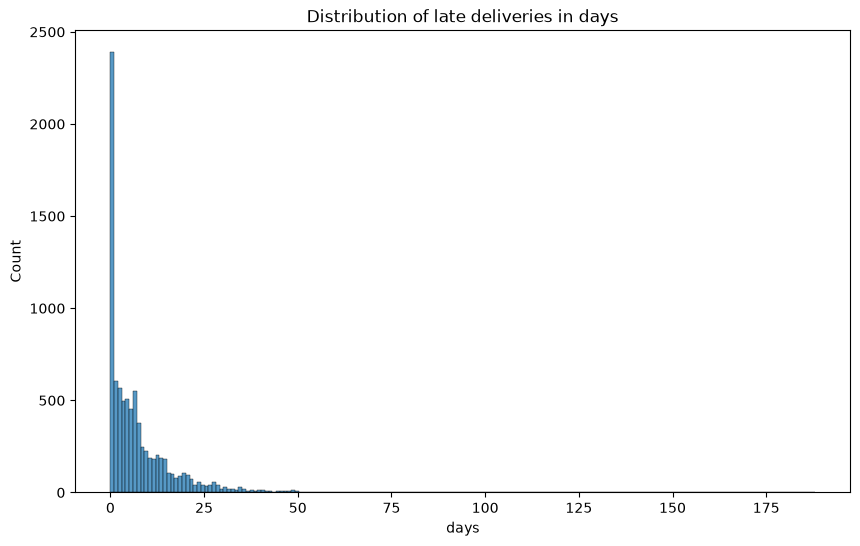

In [35]:
plt.figure(figsize=(10, 6))
sns.histplot(late_orders_customer['delivery_diff_days'])
plt.xlabel('days')
plt.title('Distribution of late deliveries in days')

In [36]:
delivery_info[delivery_info['delivery_flag'] != 'on_time']['order_id'].nunique()

7827

In [37]:
late_due_to_shipping = delivery_info[(delivery_info['carrier_delivery_flag'] == 'on_time') & (delivery_info['delivery_flag'] != 'on_time')]['order_id'].nunique()

print(f"number of deliveries late eventhough item reached carrier on time : {late_due_to_shipping}")
print(f"% of deliveries late eventhough item reached carrier on time : {round(late_due_to_shipping*100 / delivery_info[delivery_info['delivery_flag'] != 'on_time']['order_id'].nunique(), 2)} %")



number of deliveries late eventhough item reached carrier on time : 5698
% of deliveries late eventhough item reached carrier on time : 72.8 %


There are 5698 deliveries that are late eventhough seller delivered the order items to the carrier 'on time' so for these order shipping/carrier needs to be informed so the deliveries could be reached on time which is 72.80 % of the total late deliveries

In [38]:
delivery_info[(delivery_info['carrier_delivery_flag'] != 'on_time') & (delivery_info['delivery_flag'] == 'on_time')]['order_id'].nunique()

6597

There are 6597 deliveries that were done on time  eventhough seller delivered the order items to the carrier 'late' after the shipping_limit_date, still we need to inform seller about these items to deliver then 'on time' for carrier

In [39]:
late_due_to_both = delivery_info[(delivery_info['carrier_delivery_flag'] != 'on_time') & (delivery_info['delivery_flag'] != 'on_time')]['order_id'].nunique()
print(f"number of deliveries late eventhough item reached carrier on time {late_due_to_both}")
print(f"% of deliveries late eventhough item reached carrier on time {round(late_due_to_both*100 / delivery_info[delivery_info['delivery_flag'] != 'on_time']['order_id'].nunique(), 2)} %")

number of deliveries late eventhough item reached carrier on time 2129
% of deliveries late eventhough item reached carrier on time 27.2 %


There are 2129 deliveries where both seller couldn't deliver order item to the shipping/carrier and shipping also delivered the order late so both needs to be informed 

In [40]:
print(f" The revenue impacted due to late deliveries : {round(delivery_info[delivery_info['delivery_flag'] == 'late']['price'].sum()/1e6 , 2)}M $")

 The revenue impacted due to late deliveries : 1.16M $


### which product categories orders have most late deliveries?

In [41]:
orders_timeline = orders_timeline.merge(df_products, how='left', on = 'product_id').merge(df_prdduct_category, how='left', on = 'product_category_name')


In [42]:
delivery_info = orders_timeline[orders_timeline['order_delivered_customer_date'].notnull()]


late_delivery_categories = delivery_info.groupby('product_category_name_english').agg(total_orders=('order_id', 'nunique'),
    late_orders=('order_id', lambda x: x[delivery_info.loc[x.index,'delivery_flag']=='late'].nunique()),
    revenue=('price', 'sum'), freight = ('freight_value', 'mean')).reset_index()
late_delivery_categories['late_deliveries_pct'] = round(late_delivery_categories['late_orders']*100 / late_delivery_categories['total_orders'], 2) 
late_delivery_categories.sort_values(['late_orders'], ascending=False).head(10)

,product_category_name_english,total_orders,late_orders,revenue,freight,late_deliveries_pct
7,bed_bath_table,9272,811,1023434.76,18.421848,8.75
43,health_beauty,8649,776,1233211.61,18.907980,8.97
65,sports_leisure,7530,584,954695.05,19.381268,7.76
39,furniture_decor,6307,535,711927.69,20.637528,8.48
15,computers_accessories,6529,503,888613.62,18.839465,7.70
70,watches_gifts,5493,468,1165898.98,16.752262,8.52
49,housewares,5743,399,615628.69,21.010090,6.95
68,telephony,4093,349,309860.23,15.652910,8.53
5,auto,3809,328,578849.35,21.858074,8.61
69,toys,3804,286,471197.48,18.801533,7.52


In [43]:
late_delivery_products = delivery_info.groupby('product_id').agg(total_orders=('order_id', 'nunique'),
    late_orders=('order_id', lambda x: x[delivery_info.loc[x.index,'delivery_flag']=='late'].nunique()),
    revenue=('price', 'sum'), freight = ('freight_value', 'mean')).reset_index()
late_delivery_products['late_deliveries_pct'] = round(late_delivery_products['late_orders']*100 / late_delivery_products['total_orders'], 2) 
late_delivery_products.sort_values(['late_orders'], ascending=False).head(10)

,product_id,total_orders,late_orders,revenue,freight,late_deliveries_pct
8428,422879e10f46682990de24d770e7f83d,352,43,26577.22,15.752149,12.22
8123,3fbc0ef745950c7932d5f2a446189725,143,38,9797.51,26.057987,26.57
7205,389d119b48cf3043d311335e499d9c6b,309,36,21336.79,18.479128,11.65
21615,aca2eb7d00ea1a7b8ebd4e68314663af,425,36,37104.30,13.641250,8.47
3342,19c91ef95d509ea33eda93495c4d3481,153,35,18643.46,35.029545,22.88
19289,99a4788cb24856965c36a24e339b6058,456,32,42049.66,16.473459,7.02
10588,53759a2ecddad2bb87a079a1f1519f73,287,32,20387.20,18.447802,11.15
23544,bb50f2e236e5eea0100680137654686c,186,31,63560.00,19.062010,16.67
28848,e53e557d5a159f5aa2c5e995dfdf244b,154,28,15263.44,16.081602,18.18
6925,368c6c730842d78016ad823897a372db,291,28,21056.80,17.854639,9.62


### These are the top 10 product categories by revenue for which there are most late deliveries 

In [44]:
orders_timeline = orders_timeline.merge(df_customers, how='left', on = 'customer_id')

In [45]:
delivery_info = orders_timeline[orders_timeline['order_delivered_customer_date'].notnull()]

late_delivery_location = delivery_info.groupby('customer_city').agg(total_orders=('order_id', 'nunique'),
    late_orders=('order_id', lambda x: x[delivery_info.loc[x.index,'delivery_flag']=='late'].nunique()),
    revenue=('price', 'sum'), freight = ('freight_value', 'mean')).reset_index()
late_delivery_location['late_deliveries_pct'] = round(late_delivery_location['late_orders']*100 / late_delivery_location['total_orders'], 2) 
late_delivery_location.sort_values(['total_orders','late_orders'], ascending=False).head(10)

,customer_city,total_orders,late_orders,revenue,freight,late_deliveries_pct
3563,sao paulo,15046,942,1859666.63,14.276161,6.26
3126,rio de janeiro,6604,780,955945.36,20.565847,11.81
449,belo horizonte,2697,166,346039.04,19.407668,6.15
553,brasilia,2071,147,295814.72,21.095399,7.10
1135,curitiba,1489,74,205999.33,18.795825,4.97
700,campinas,1406,143,184657.87,14.972343,10.17
2936,porto alegre,1341,158,182140.55,20.656037,11.78
3218,salvador,1188,208,173273.05,25.361009,17.51
1518,guarulhos,1143,72,138897.20,14.476667,6.30
3398,sao bernardo do campo,911,57,102514.23,13.708309,6.26


In [46]:
## Which customers are repeated ?
## which product categories they are interested in ?
## which orders late deliveries vs their reviews
## time series analysis of orders 
## monthly orders trend
# which hours of the day have maximum orders 

### Which customers are ordering repeated ? what perecntage of customers are new ?

In [47]:
customers = df_orders.merge(df_customers, how='left', on = 'customer_id')
customers.shape[0]

99441

In [48]:
customer_orders = customers.groupby('customer_unique_id').agg(orders = ('order_id', 'count') ).sort_values('orders', ascending=False).reset_index()
customer_orders.head(10)

,customer_unique_id,orders
0,8d50f5eadf50201ccdcedfb9e2ac8455,17
1,3e43e6105506432c953e165fb2acf44c,9
2,1b6c7548a2a1f9037c1fd3ddfed95f33,7
3,6469f99c1f9dfae7733b25662e7f1782,7
4,ca77025e7201e3b30c44b472ff346268,7
5,47c1a3033b8b77b3ab6e109eb4d5fdf3,6
6,12f5d6e1cbf93dafd9dcc19095df0b3d,6
7,63cfc61cee11cbe306bff5857d00bfe4,6
8,dc813062e0fc23409cd255f7f53c7074,6
9,de34b16117594161a6a89c50b289d35a,6


#### In 2 years time span these are top 10 customers who ordered repeatedly

In [49]:
customer_orders[customer_orders['orders'] > 1].shape[0]

2997

In [50]:
print(f"repeated customers : {customer_orders[customer_orders['orders'] > 1].shape[0]}")
print(f'total cunstomers : {df_customers['customer_unique_id'].nunique()}')
print(f'% repeated customers : {round(customer_orders[customer_orders['orders'] > 1].shape[0] * 100 /df_customers['customer_unique_id'].nunique() , 2)}%')

repeated customers : 2997
total cunstomers : 96096
% repeated customers : 3.12%


#### only 3.12% of returning customers is concerning so there needs to be some changes regarding the product pages, delivery times, discounts to revisit the website and buy again

In [51]:
df_reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 5.3 MB


In [52]:
df_reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

#### the review scores are not null, review title and review comment message has null values but these are optional fields so even b review score we can understand what customer feels. review_creation_date and review_answer_timestamp needs to be converted to date time

In [53]:
df_reviews['review_answer_timestamp'] = pd.to_datetime(df_reviews['review_answer_timestamp'])
df_reviews['review_creation_date'] = pd.to_datetime(df_reviews['review_creation_date'])

In [54]:
orders_review = delivery_info.merge(df_reviews, how='left', on = 'order_id')

In [55]:
orders_review_summary = orders_review.groupby(['review_score', 'delivery_flag']).agg(customers = ('order_id', 'nunique'), sale = ('price', sum), freight = ('freight_value', 'sum')).sort_values(['review_score', 'delivery_flag']).reset_index()
orders_review_summary

,review_score,delivery_flag,customers,sale,freight
0,1.0,late,3543,560430.24,91637.79
1,1.0,on_time,5841,991020.30,173238.74
2,2.0,late,604,81995.57,14668.25
3,2.0,on_time,2334,340521.18,62769.76
4,3.0,late,876,119194.32,21311.74
5,3.0,on_time,7067,895701.75,166188.47
6,4.0,late,950,126890.72,21537.22
7,4.0,on_time,17993,2381489.63,402858.51
8,5.0,late,1709,240639.50,39595.42
9,5.0,on_time,55102,7429845.90,1199079.76


In [56]:
orders_review.shape

(110839, 40)

### H_0 : The review scores and late deliveries are independent
### H_1 : There is some relation between the review scores and late deliveries

In [57]:
review_contingency = orders_review.groupby('review_score').agg( late_orders=('order_id', lambda x: x[orders_review.loc[x.index,'delivery_flag']=='late'].nunique()),
                                           ontime_orders=('order_id', lambda x: x[orders_review.loc[x.index,'delivery_flag']=='on_time'].nunique()), 
                                          ).reset_index()
review_contingency

,review_score,late_orders,ontime_orders
0,1.0,3543,5841
1,2.0,604,2334
2,3.0,876,7067
3,4.0,950,17993
4,5.0,1709,55102


In [58]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(review_contingency.set_index('review_score'))

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square statistic: 14169.344921618906
p-value: 0.0
Degrees of freedom: 4


Since The p_value < 0.05 hence we reject null Hypothesis H_0 and conclude there is association between late deliveries and review_scores
i.e review_score is less if the delivery is late

In [59]:
orders_review_summary = orders_review_summary.merge(orders_review['review_score'].value_counts().reset_index(), on = 'review_score', how='left' )

In [60]:
orders_review_summary["% of customers reveiw"] = round(orders_review_summary['customers']*100 /orders_review_summary['count'], 2)
orders_review_summary["% of total customers reveiw score"] = round(orders_review_summary['customers']*100 /delivery_info['order_id'].nunique(), 2)
orders_review_summary["% of total revenue according to  reveiw"] = round(orders_review_summary['sale']*100/valid_orders['sale'].sum(), 2)

In [61]:
orders_review_summary


,review_score,delivery_flag,customers,sale,freight,count,% of customers reveiw,% of total customers reveiw score,% of total revenue according to reveiw
0,1.0,late,3543,560430.24,91637.79,12578,28.17,3.67,4.15
1,1.0,on_time,5841,991020.30,173238.74,12578,46.44,6.05,7.34
2,2.0,late,604,81995.57,14668.25,3700,16.32,0.63,0.61
3,2.0,on_time,2334,340521.18,62769.76,3700,63.08,2.42,2.52
4,3.0,late,876,119194.32,21311.74,9243,9.48,0.91,0.88
5,3.0,on_time,7067,895701.75,166188.47,9243,76.46,7.33,6.64
6,4.0,late,950,126890.72,21537.22,21184,4.48,0.98,0.94
7,4.0,on_time,17993,2381489.63,402858.51,21184,84.94,18.65,17.65
8,5.0,late,1709,240639.50,39595.42,63307,2.70,1.77,1.78
9,5.0,on_time,55102,7429845.90,1199079.76,63307,87.04,57.11,55.06


##### Deliveries that were delivered on time are getting good review score like 4 and 5 but same logic is not applicable for review scores 3, 2 and 1, but there must be other factors as well which customers are disappointed about and hence giving bad scores.

# Time series Analysis

In [62]:
df_orders["purchase_month_year"] = df_orders['order_purchase_timestamp'].dt.strftime("%b-%Y")
df_orders["purchase_month_year"] = pd.to_datetime(df_orders["purchase_month_year"], format="%b-%Y")


In [63]:
monthwise_orders = df_orders.groupby('purchase_month_year').agg(orders = ("order_id", "nunique")).sort_values('purchase_month_year').reset_index()


Text(0.5, 1.0, 'Monthly Oreders trend')

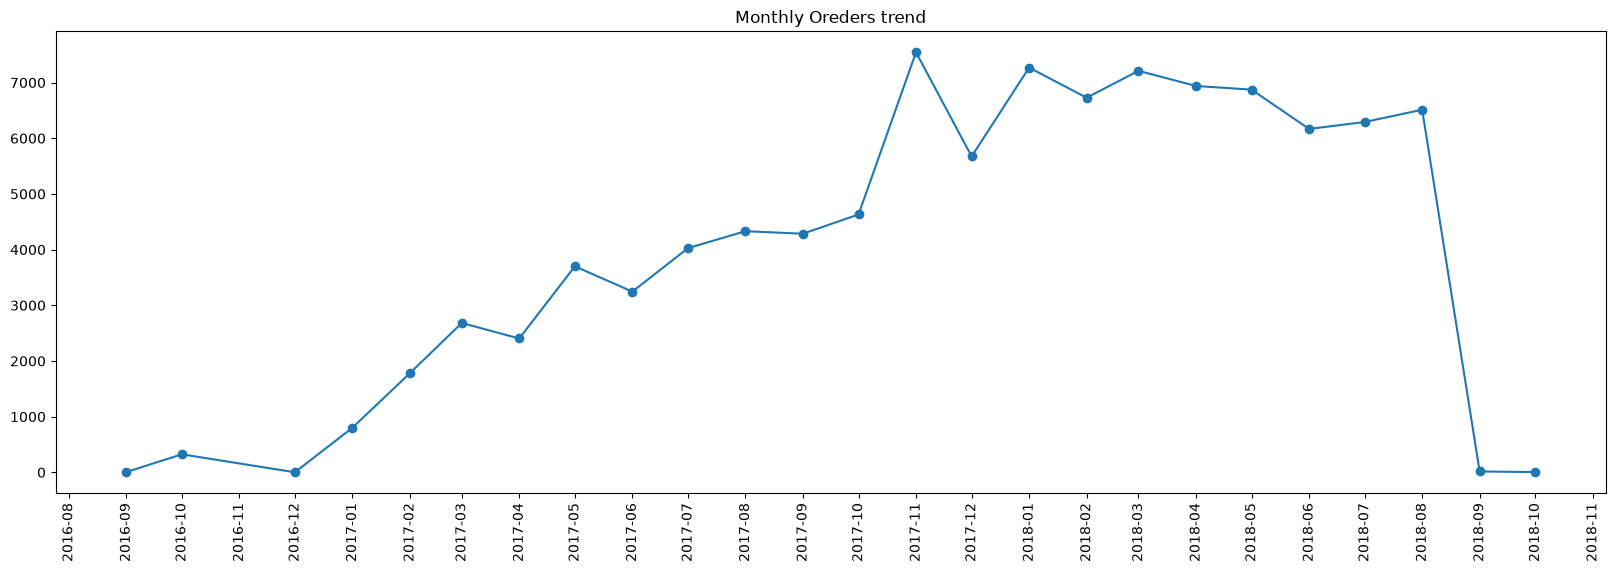

In [64]:
import matplotlib.dates as mdates
fig, ax = plt.subplots(figsize=(20, 6))

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))

# 3. Format how the dates look (YYYY-MM to match your image)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# 4. Rotate the labels so they don't overlap
plt.xticks(rotation=90)


plt.plot(monthwise_orders['purchase_month_year'], monthwise_orders['orders'], marker = 'o')

plt.xticks( rotation =90 )
plt.title('Monthly Oreders trend')

In [65]:
df_orders['purchase_hour'] = df_orders['order_purchase_timestamp'].dt.hour

<Axes: xlabel='purchase_hour', ylabel='count'>

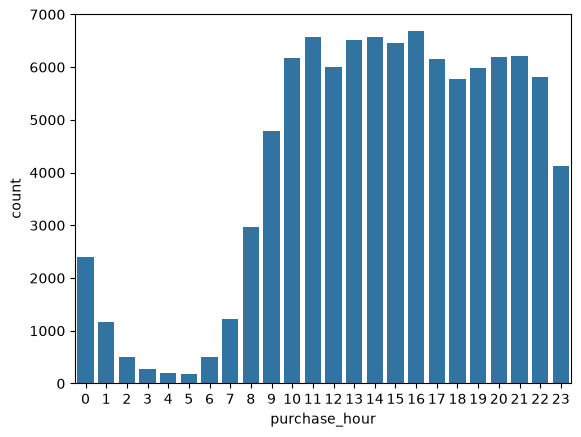

In [66]:
sns.barplot(x= df_orders['purchase_hour'].value_counts().reset_index()['purchase_hour'], y = df_orders['purchase_hour'].value_counts().reset_index()['count'])

##### Most customers are ordering between 10 to 22 hours of the day, so we need to ensure the site handles the traffic smoothly during this period the hours 10, 12,13, 14, 16 has higher orders than the other time

#### Which product_categories have the highest demand ? 

In [67]:
orders_timeline.groupby('product_category_name_english').agg(orders = ('order_id', 'nunique'), sales = ('price', 'sum'), sellers = ('seller_id', 'nunique')).sort_values('sales', ascending= False).reset_index().head(10)

,product_category_name_english,orders,sales,sellers
0,health_beauty,8836,1258681.34,492
1,watches_gifts,5624,1205005.68,101
2,bed_bath_table,9417,1036988.68,196
3,sports_leisure,7720,988048.97,481
4,computers_accessories,6689,911954.32,287
5,furniture_decor,6449,729762.49,370
6,cool_stuff,3632,635290.85,267
7,housewares,5884,632248.66,468
8,auto,3897,592720.11,383
9,garden_tools,3518,485256.46,237


In [68]:
orders_timeline.groupby('seller_id').agg(orders = ('order_id', 'nunique'), sales = ('price', 'sum'),).sort_values('sales', ascending= False).reset_index().head(10)

,seller_id,orders,sales
0,4869f7a5dfa277a7dca6462dcf3b52b2,1132,229472.63
1,53243585a1d6dc2643021fd1853d8905,358,222776.05
2,4a3ca9315b744ce9f8e9374361493884,1806,200472.92
3,fa1c13f2614d7b5c4749cbc52fecda94,585,194042.03
4,7c67e1448b00f6e969d365cea6b010ab,982,187923.89
5,7e93a43ef30c4f03f38b393420bc753a,336,176431.87
6,da8622b14eb17ae2831f4ac5b9dab84a,1314,160236.57
7,7a67c85e85bb2ce8582c35f2203ad736,1160,141745.53
8,1025f0e2d44d7041d6cf58b6550e0bfa,915,138968.55
9,955fee9216a65b617aa5c0531780ce60,1287,135171.70


In [69]:
orders_timeline['product_volume'] = orders_timeline['product_length_cm']*orders_timeline['product_height_cm']*orders_timeline['product_width_cm']
orders_timeline['product_density'] = round(orders_timeline['product_weight_g']/orders_timeline['product_volume'],2)

<Axes: xlabel='product_volume', ylabel='freight_value'>

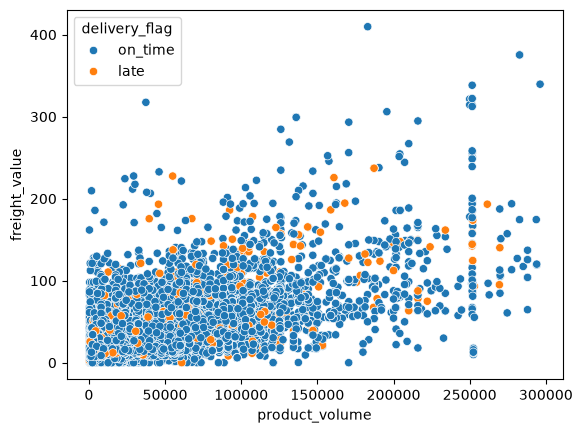

In [70]:
plot_df = orders_timeline[orders_timeline['order_delivered_customer_date'].notnull()]
sns.scatterplot(data=plot_df, x=plot_df['product_volume'], y=plot_df['freight_value'], hue=plot_df['delivery_flag'])

<Axes: xlabel='product_volume', ylabel='price'>

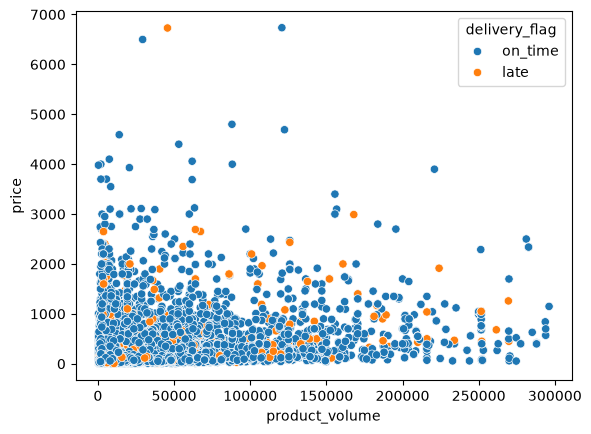

In [71]:
plot_df = orders_timeline[orders_timeline['order_delivered_customer_date'].notnull()]
sns.scatterplot(data=plot_df, x=plot_df['product_volume'], y=plot_df['price'], hue=plot_df['delivery_flag'])

##### There is no correlation between the product volume and freight value like the high volume means high freight there may be other parameters the fragile products like electronic devices, or sensetive products which were charged freight accordingly